# Week 1 - Tasks

- **Data Source:** `yfinance`
- **Assets:** `AAPL`, `MSFT`, `GOOG`, `AMZN`, `TSLA` (and `NVDA` for Task 5)
- **Timeframes:**
  * **Long Term:** `start="2015-01-01", end="2024-01-01"`
  * **Medium Term:** `start="2020-01-01", end="2024-01-01"` (Includes COVID crash)

The goal for this week is to gain familiarity with financial data, analyze common trends, learn standard library functions, and touch upon the underlying theory.

## Task 1 - Setup
* Fetch **Long Term** historical data for the 5 assets.
* Extract the `Adjusted Close` values.
    * *Note: Check for missing values or empty rows and handle them (drop or fill).*
* Use `df.describe()` to extract key summary statistics.
* Extract the **Medium Term** data as well for later tasks.

In [7]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from scipy.stats import skew, kurtosis

# Set visual style
sns.set(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Define assets
assets = ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'TSLA']
task5_asset = 'NVDA'
all_tickers = assets + [task5_asset]

# Fetch Long Term (2015-2024)
# auto_adjust=False ensures 'Adj Close' is not renamed to 'Close'
raw_data = yf.download(all_tickers, start="2015-01-01", end="2024-01-01", auto_adjust=False)

# Extract Adjusted Close. If 'Adj Close' is missing, fallback to 'Close'
if 'Adj Close' in raw_data.columns:
    lt_data = raw_data['Adj Close']
else:
    lt_data = raw_data['Close']

# Handle missing values
lt_data = lt_data.ffill().dropna()

# Extract Medium Term (2020-2024)
mt_data = lt_data.loc["2020-01-01":"2024-01-01"]

print("Summary Statistics (Long Term):")
print(lt_data[assets].describe())

[*********************100%***********************]  6 of 6 completed

Summary Statistics (Long Term):
Ticker         AAPL         MSFT         GOOG         AMZN         TSLA
count   2264.000000  2264.000000  2264.000000  2264.000000  2264.000000
mean      81.394710   154.516908    73.063479    91.950540   102.886245
std       55.990880    99.658478    36.298158    48.654536   110.936400
min       20.604076    34.437172    24.377237    14.347500     9.578000
25%       32.814702    59.182489    41.515257    44.303625    16.670500
50%       51.220842   127.528831    59.376663    90.691998    23.160666
75%      139.017635   244.037369   104.133982   133.230000   214.290005
max      196.256546   377.077881   149.587082   186.570496   409.970001


## Task 2 - Basic Trends
* Select **one asset** and using the **Medium Term** data, compute:
    * **Returns:** 1-day, 5-day, and 20-day simple returns.
    * **Log Returns:** 1-day, 5-day, and 20-day log returns.
    * **Volatility:** 5-day, 20-day, and 60-day rolling standard deviation (volatility) of the log returns.
* **Plotting:**
    * Plot the price and the 20-day moving average on one chart.
    * Plot the 1-day log returns on a separate chart.
    * Plot the rolling volatilities on a third chart.
    * *Analysis:* What trends do you observe? Does high volatility correlate with price drops?

* **Bonus (Long Term Data):**
    * Create a scatter plot of `|Daily Return|` vs `Volume`. Is there a relationship?
    * Group returns and volatility by **Month** (e.g., all Januaries, all Februaries) and plot the averages. Is there a "seasonal" effect?

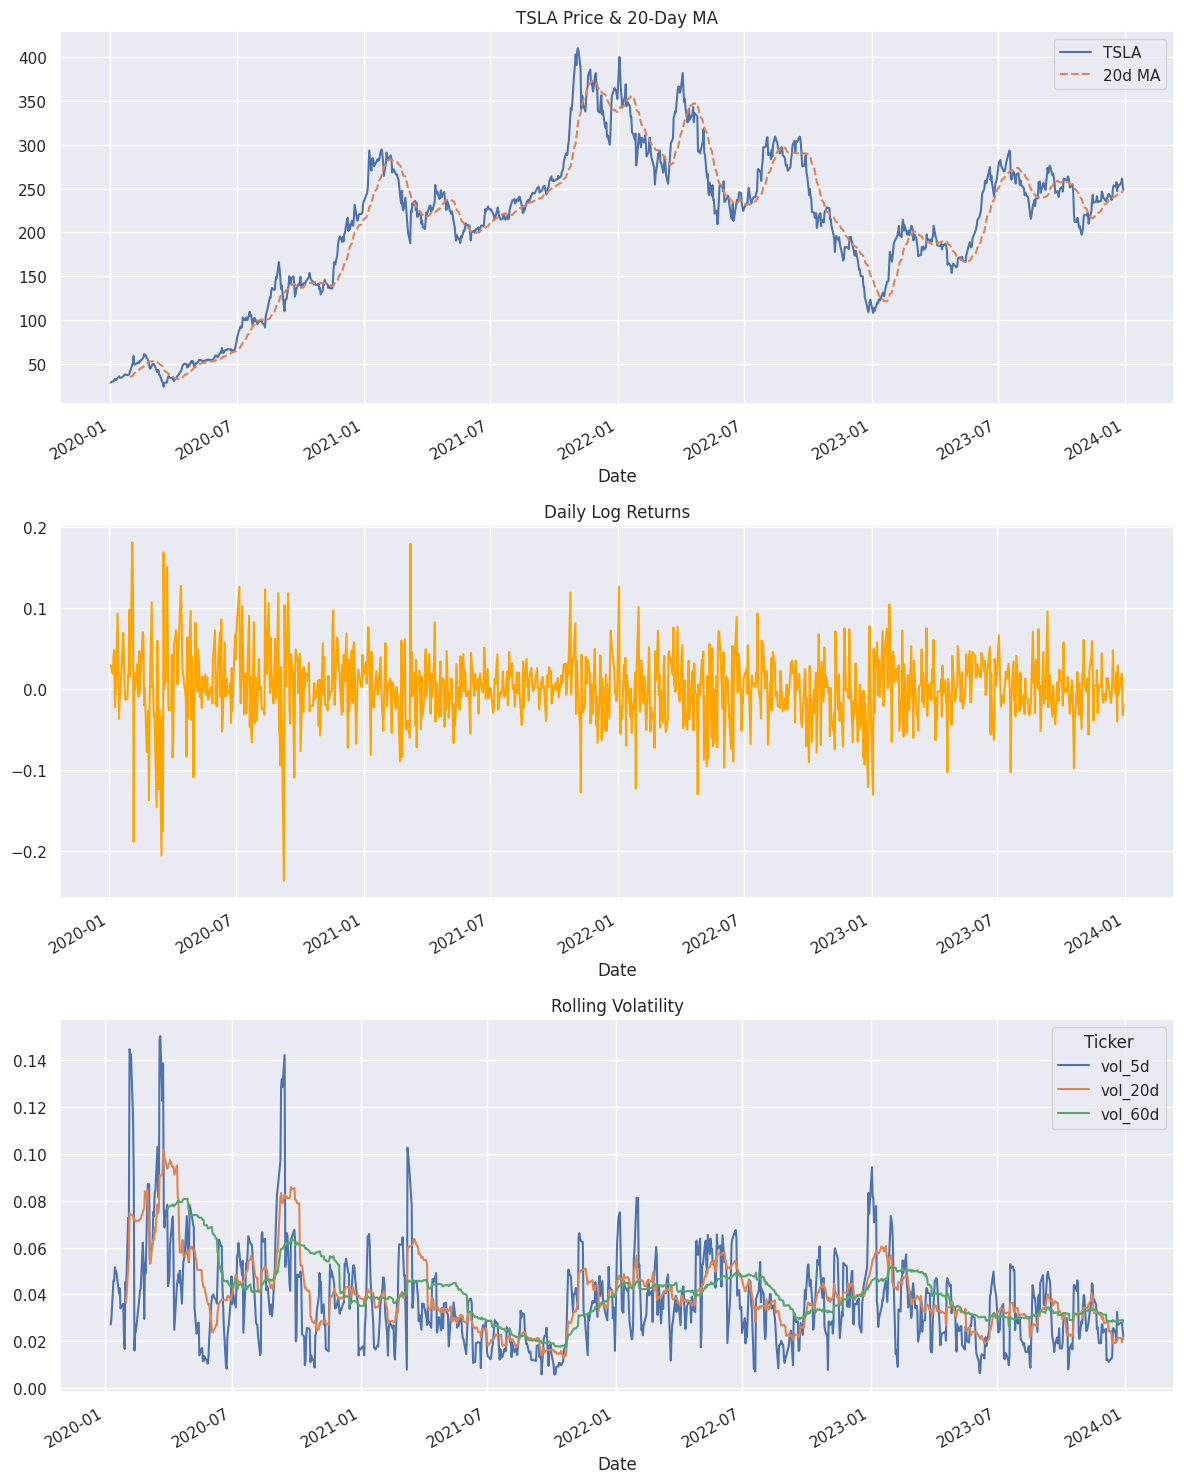

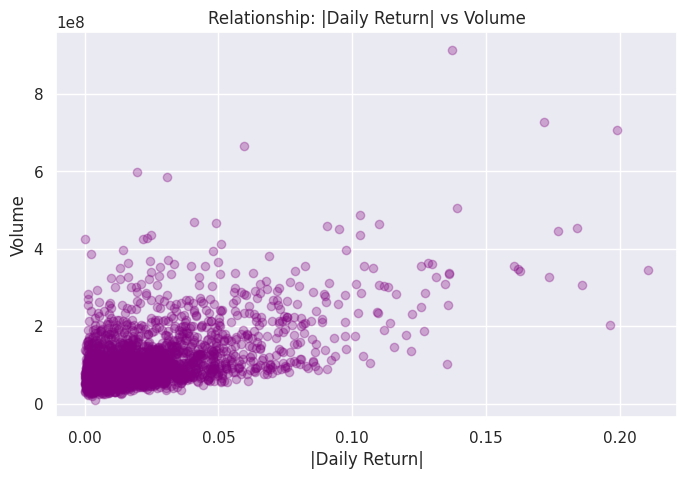

In [8]:
# Using TSLA for analysis
asset = 'TSLA'
df_mt = mt_data[[asset]].copy()

# 1. Returns and Log Returns
df_mt['1d_ret'] = df_mt[asset].pct_change()
df_mt['5d_ret'] = df_mt[asset].pct_change(5)
df_mt['20d_ret'] = df_mt[asset].pct_change(20)
df_mt['1d_log_ret'] = np.log(df_mt[asset] / df_mt[asset].shift(1))

# 2. Volatility (Rolling Std Dev of Log Returns)
df_mt['vol_5d'] = df_mt['1d_log_ret'].rolling(5).std()
df_mt['vol_20d'] = df_mt['1d_log_ret'].rolling(20).std()
df_mt['vol_60d'] = df_mt['1d_log_ret'].rolling(60).std()

# 3. Plotting
fig, axes = plt.subplots(3, 1, figsize=(12, 15))

# Chart 1: Price and 20-day Moving Average
df_mt[asset].plot(ax=axes[0], title=f"{asset} Price & 20-Day MA")
df_mt[asset].rolling(20).mean().plot(ax=axes[0], label='20d MA', ls='--')
axes[0].legend()

# Chart 2: 1-day log returns
df_mt['1d_log_ret'].plot(ax=axes[1], title="Daily Log Returns", color='orange')

# Chart 3: Rolling Volatilities
df_mt[['vol_5d', 'vol_20d', 'vol_60d']].plot(ax=axes[2], title="Rolling Volatility")
plt.tight_layout()
plt.show()

# BONUS: Daily Return vs Volume
# We fetch volume from the original raw_data (downloaded in Task 1)
lt_volume = raw_data['Volume'][asset]
daily_abs_ret = np.abs(lt_data[asset].pct_change())

plt.figure(figsize=(8, 5))
plt.scatter(daily_abs_ret, lt_volume, alpha=0.3, color='purple')
plt.title("Relationship: |Daily Return| vs Volume")
plt.xlabel("|Daily Return|")
plt.ylabel("Volume")
plt.show()

## Task 3 - Stationarity
* Select **one asset** (Long Term).
* Compute the **Rolling Mean** and **Rolling Standard Deviation** of log returns with window sizes `20, 60, 120`.
* Plot them and visually inspect.
    * Does the mean stay constant? (Stationary mean)
    * Does the variance stay constant? (Stationary variance)
* Run an **Augmented Dickey-Fuller (ADF) Test** on the log return series.
    * Library: `from statsmodels.tsa.stattools import adfuller`
    * *Goal:* Interpret the p-value. The Null Hypothesis ($H_0$) is that the series is non-stationary (has a unit root). If p-value < 0.05, we reject $H_0$.
    * For learning about hypothesis testing and p-value you can refer to CS215 slides or other standard resources mentioned in READMEs.

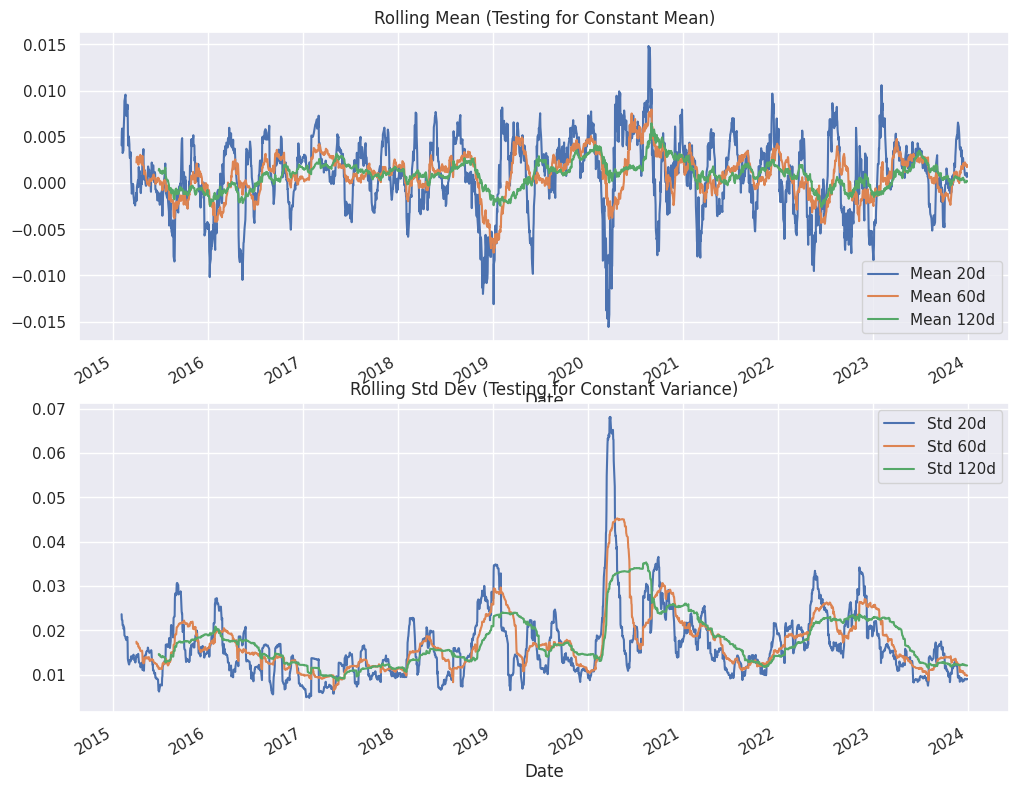

ADF Statistic: -14.7153
p-value: 0.0000
Interpretation: p < 0.05. We reject the Null Hypothesis. The series is stationary.


In [9]:
# Select AAPL for Long Term stationarity test
st_asset = 'AAPL'
log_rets = np.log(lt_data[st_asset] / lt_data[st_asset].shift(1)).dropna()

# 1. Rolling Mean and Std Dev with multiple windows
windows = [20, 60, 120]
fig, ax = plt.subplots(2, 1, figsize=(12, 10))
for w in windows:
    log_rets.rolling(w).mean().plot(ax=ax[0], label=f'Mean {w}d')
    log_rets.rolling(w).std().plot(ax=ax[1], label=f'Std {w}d')
ax[0].set_title("Rolling Mean (Testing for Constant Mean)")
ax[1].set_title("Rolling Std Dev (Testing for Constant Variance)")
ax[0].legend(); ax[1].legend()
plt.show()

# 2. Augmented Dickey-Fuller (ADF) Test
# H0: Series is non-stationary
result = adfuller(log_rets)
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')

if result[1] < 0.05:
    print("Interpretation: p < 0.05. We reject the Null Hypothesis. The series is stationary.")
else:
    print("Interpretation: p >= 0.05. We fail to reject the Null Hypothesis. The series is non-stationary.")

## Task 4 - Volatility Regimes
We try to study the trend in volatility more deeply. From the ACF/PACF plot we know that volatility tends to cluster that is the market is either in a high volatility state (greater daily fluctuations) or low volatility state (stable prices, quiet markets).

Formally we can treat volatility as a *conditional standard deviation of returns*, conditioned on the history observed so far. We *cannot* predict *true* volatility for a given day based on the single return value, hence we try to estimate it using the past information. For this we look at two indicators of volatility:

1.  **Rolling Window Volatility:** Simple Moving Average (SMA) of standard deviation.
2.  **EWMA Volatility:** Exponentially Weighted Moving Average. This gives more weight to recent events. It is given by $\sigma_t^2 = (1-\lambda)r_t^2 + \lambda \sigma_{t-1}^2$.

**Steps:**
* Pick an asset and use data covering the **Feb-Mar 2020 COVID crash**.
* Compute two volatility estimates on the Log Returns:
    1.  **Rolling 20-day Volatility:** Standard deviation over a 20-day window.
    2.  **EWMA Volatility (RiskMetrics):** Use a decay factor $\lambda = 0.94$.
        * *Hint:* In pandas `df.ewm()`, the parameter `alpha` corresponds to $1 - \lambda$. So, use `alpha=0.06`.
* **Analysis:**
    * Plot both estimates on the same chart.
    * Which is smoother?
    * Which estimator reacts faster to the sudden crash in March 2020?
    * Which one would you prefer for risk management?
* **Regime Detection:** Compute the 60th percentile of your EWMA volatility series. Shade the regions on the plot where volatility exceeds this level.

* **Bonus:** A good volatility model "standardizes" the returns well. Calculate $z_t = r_t / \hat{\sigma}_t$. If the model is good, $z_t$ should have $Var \approx 1$. Check the variance of $z_t$ and plot its histogram.

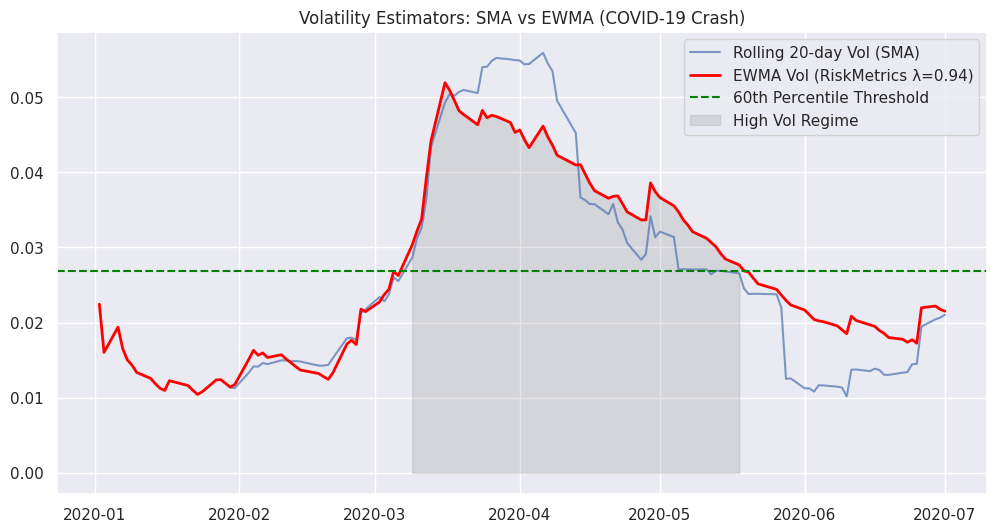

Variance of standardized returns (Model Quality): 0.9872


In [10]:
# Pick GOOG and slice for COVID period
covid_rets = np.log(lt_data['GOOG'] / lt_data['GOOG'].shift(1)).loc["2020-01-01":"2020-07-01"].dropna()

# 1. Rolling 20-day Volatility
vol_rolling = covid_rets.rolling(20).std()

# 2. EWMA Volatility (alpha = 1 - lambda; 1 - 0.94 = 0.06)
# Formula: sigma_t^2 = (1-lambda)r_t^2 + lambda*sigma_{t-1}^2
vol_ewma = np.sqrt(covid_rets.pow(2).ewm(alpha=0.06).mean())

# 3. Plotting and Regime Detection
plt.figure(figsize=(12, 6))
plt.plot(vol_rolling, label='Rolling 20-day Vol (SMA)', alpha=0.7)
plt.plot(vol_ewma, label='EWMA Vol (RiskMetrics λ=0.94)', color='red', lw=2)

# Shade regions where EWMA volatility exceeds 60th percentile
threshold = vol_ewma.quantile(0.60)
plt.axhline(threshold, color='green', linestyle='--', label='60th Percentile Threshold')
plt.fill_between(vol_ewma.index, 0, vol_ewma, where=(vol_ewma > threshold), color='gray', alpha=0.2, label='High Vol Regime')

plt.title("Volatility Estimators: SMA vs EWMA (COVID-19 Crash)")
plt.legend()
plt.show()

# BONUS: Standardized returns check
z_t = covid_rets / vol_ewma
print(f"Variance of standardized returns (Model Quality): {z_t.var():.4f}")

## Task 5 - Time Horizons and the "Normal" Illusion
Short-term markets are noisy and dangerous (fat tails), while long-term data looks smoother. We can prove this statistically using **Skew** and **Kurtosis**.

**Theory:**
* **Skewness:** Measures asymmetry. (Negative skew = frequent small gains, few extreme losses).
* **Kurtosis:** Measures "tailedness". (High kurtosis = frequent extreme events/crashes).
* **Normal Distribution:** Skew $\approx 0$, Kurtosis $\approx 3$ (or Excess Kurtosis $\approx 0$).

**Steps:**
1.  Take your **Long Term** data for one asset (e.g., NVDA or TSLA).
2.  Resample the prices to get **Weekly** and **Monthly** closes.
    * Use `df['Adj Close'].resample('W').last()` and `...resample('M').last()`.
3.  Compute Log Returns for all three series: Daily, Weekly, Monthly.
4.  **The Test:**
    * Calculate **Skew** and **Kurtosis** for each of the three return series.
    * *Question:* How do these values change as the time horizon increases? Do they get closer to 0 and 3?
5.  **Visualization:**
    * Plot the **Histograms** of the Daily returns vs. Monthly returns on the same plot.
    * *Tip:* You will need to standardize them (subtract mean, divide by std dev) to overlay them meaningfully.
    * *Observation:* Look at the tails. Which one has "fatter" tails (more extreme outliers)?

**Key Takeaway:**
Daily returns often violate the "Normal Distribution" assumption used in many financial models. Long-term returns fit it better. This is called *Aggregational Gaussianity*.

**Bonus:** This is a direct application of a simple yet well-known result in asymptotic statistics. Can you find out what it is and state how it explains this observation?

/tmp/ipykernel_5019/917452423.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_prices = nvda_prices.resample('M').last()


Normality Test across Horizons:
         Skewness  Kurtosis (Target=3)
Daily    0.209866            10.512806
Weekly   0.102130             4.363784
Monthly -0.552561             3.602166


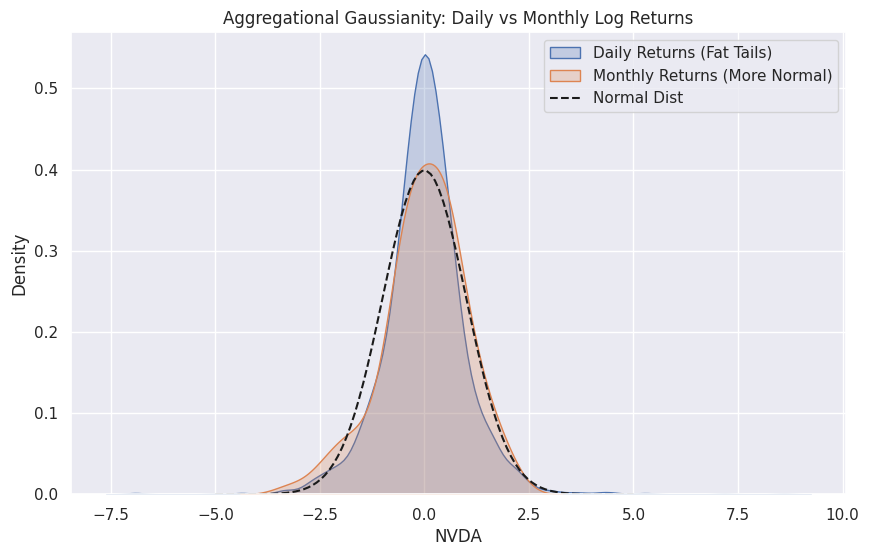

In [11]:
# Using NVDA for Long Term analysis
nvda_prices = lt_data['NVDA']

# 1. Resample Prices
weekly_prices = nvda_prices.resample('W').last()
monthly_prices = nvda_prices.resample('M').last()

# 2. Compute Log Returns
d_log = np.log(nvda_prices / nvda_prices.shift(1)).dropna()
w_log = np.log(weekly_prices / weekly_prices.shift(1)).dropna()
m_log = np.log(monthly_prices / monthly_prices.shift(1)).dropna()

# 3. Skew and Kurtosis (Excess Kurtosis + 3 = Fisher Kurtosis)
def get_stats(series):
    return [skew(series), kurtosis(series, fisher=False)]

norm_stats = pd.DataFrame({
    'Daily': get_stats(d_log),
    'Weekly': get_stats(w_log),
    'Monthly': get_stats(m_log)
}, index=['Skewness', 'Kurtosis (Target=3)']).T

print("Normality Test across Horizons:")
print(norm_stats)

# 4. Visualization: Daily vs Monthly Standardized
plt.figure(figsize=(10, 6))
sns.kdeplot((d_log - d_log.mean()) / d_log.std(), label='Daily Returns (Fat Tails)', fill=True)
sns.kdeplot((m_log - m_log.mean()) / m_log.std(), label='Monthly Returns (More Normal)', fill=True)

# Overlay a theoretical Normal distribution for reference
x = np.linspace(-5, 5, 100)
plt.plot(x, [1/np.sqrt(2*np.pi)*np.exp(-0.5*i**2) for i in x], 'k--', label='Normal Dist')

plt.title("Aggregational Gaussianity: Daily vs Monthly Log Returns")
plt.legend()
plt.show()

# BONUS: The result is the Central Limit Theorem. 
# Summing i.i.d (or weakly dependent) variables leads to a Normal distribution.

## Task 6 - Smart investing
Calculate how many **RTX 4090s** (approx. price $1,600$) you could afford *today* if you had invested **$1,000** in NVIDIA on the day you were born.

In [12]:
# Assuming a birth date (Update this to your actual birth date)
birth_date = "2006-12-12" 

# Fetch price at birth and today
nvda_ticker = yf.Ticker("NVDA")
birth_price_df = nvda_ticker.history(start=birth_date)

if not birth_price_df.empty:
    price_at_birth = birth_price_df.iloc[0]['Close']
    # Use current price from the last available trading day
    price_now = nvda_ticker.history(period="1d")['Close'].iloc[-1]

    # Calculation
    initial_investment = 1000
    shares_owned = initial_investment / price_at_birth
    total_value = shares_owned * price_now
    
    rtx_4090_cost = 1600
    affordable_gpus = total_value / rtx_4090_cost

    print(f"NVDA price on {birth_date}: ${price_at_birth:.4f}")
    print(f"NVDA price today: ${price_now:.2f}")
    print(f"Your $1,000 investment would be worth: ${total_value:,.2f}")
    print(f"You could buy {int(affordable_gpus)} RTX 4090s today.")
else:
    print("The market was likely closed on your birth date or ticker history is unavailable. Try an earlier date.")

NVDA price on 2006-12-12: $0.5469
NVDA price today: $186.50
Your $1,000 investment would be worth: $341,018.16
You could buy 213 RTX 4090s today.
